## <center> **Student Scores Prediction based on Study Hours** </center>
---

### Imports

In [50]:
import pandas as pd 
import numpy as np 
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load dataset

In [51]:
df = pd.read_csv("students_score.csv")
df.tail()

,Hours,Scores
91,5.8,60
92,4.4,44
93,6.1,63
94,3.7,37
95,8.0,84


### Rows and Columns

In [52]:
df.shape

(96, 2)

### Basic Information

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   96 non-null     float64
 1   Scores  96 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.6 KB


### Statistical Summary

In [54]:
df.describe()

,Hours,Scores
count,96.000000,96.000000
mean,5.267708,54.020833
std,2.503030,25.017459
min,1.000000,12.000000
25%,3.075000,30.750000
50%,5.250000,54.500000
75%,7.325000,74.250000
max,9.800000,99.000000


### Null values

In [55]:
df.isnull().sum()

Hours     0
Scores    0
dtype: int64

### Data Distribution (Boxplot)

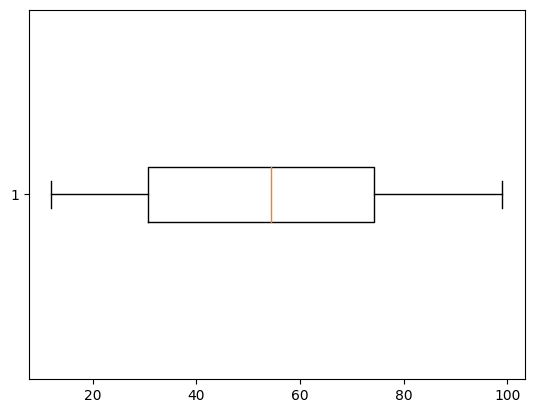

In [56]:
plt.boxplot(
    x= df["Scores"],
    vert=False,
    meanline=True
)

plt.show()

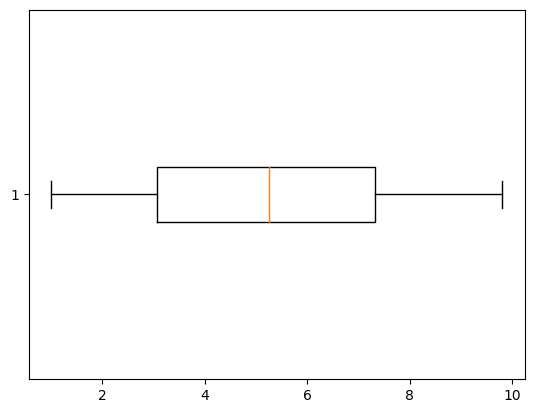

In [57]:
plt.boxplot(
    x= df["Hours"],
    vert=False,
    meanline=True
)

plt.show()

### Features and Target

In [58]:
X = df.drop("Hours", axis=1)
y = df["Scores"]

print(f"X shape: {X.shape}")
print(f"Y shape: {y.shape}")

X shape: (96, 1)
Y shape: (96,)


### Training and Testing

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

### Initialize Linear Regression

In [60]:
model = LinearRegression()

### Train Linear Regression

In [61]:
model.fit(X_train, y_train)

LinearRegression()

### Make Predictions

In [70]:
y_test_pred = model.predict(X_test)

y_train_pred = model.predict(X_train)

### Evaluate model

In [71]:
print(f"R2 Score: {r2_score(y_test, y_test_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_test_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_test_pred)}")

R2 Score: 1.0
Mean Squared Error: 1.2054780707908586e-30
Mean Absolute Error: 8.992806499463768e-16


### Regression plot

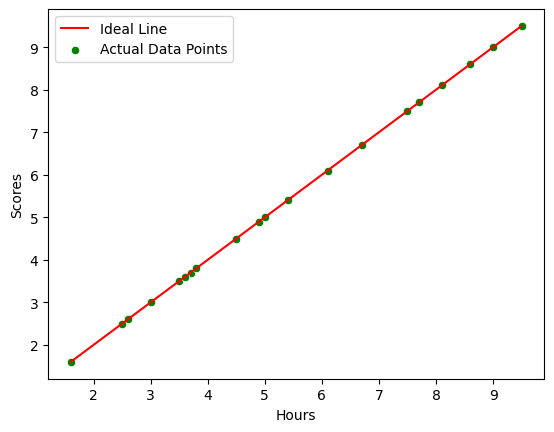

In [72]:
sns.scatterplot(
    x=y_test,
    y=y_test_pred,
    color='green',
    label='Actual Data Points'
)

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red',
    label='Ideal Line'
)

plt.legend()
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.show()

### Feature importance dataframe

In [73]:
feature_importance = pd.DataFrame({

    "Features": X_train.columns,

    "Coefficient": model.coef_
})

feature_importance

,Features,Coefficient
0,Hours,1.0


In [74]:
# Training R2 Score

r2_train = r2_score(y_train, y_train_pred)

# Testing R2 Score

r2_test = r2_score(y_test, y_test_pred)

print(f"Training R2 : {r2_train}")

print(f"Testing R2 : {r2_test}")

Training R2 : 1.0
Testing R2 : 1.0


### Save Model

In [76]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)